In [1]:
import sys

sys.path.append("../../../")

In [2]:
import math
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from torch import nn
from transformers import AutoModelForCausalLM, AutoTokenizer

from moe_pruning.common_sp_logic.sharing_utils import (
    CaptureMoEIOHook,
    _calculate_hidden_dim_similarities_logic,
    _get_activation_sparsity_scores_logic,
    _get_gradient_magnitude_scores_logic,
    _get_wanda_scores_logic,
    get_expert_down_proj,
    get_expert_gate_proj,
    get_expert_up_proj,
)

PAPER_RC: dict[str, object] = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.linestyle": ":",
    "grid.alpha": 0.4,
    "lines.linewidth": 2.0,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

sns.set_theme(style="whitegrid", rc=PAPER_RC)

METHOD_COLORS: Dict[str, str] = {
    "oracle": "#4D4D4D",
    "gradient_magnitude": "#E15759",
    "wanda": "#4E79A7",
    "activation_sparsity": "#59A14F",
    "min_norm": "#F28E2B",
    "max_similarity": "#B07AA1",
}

METHOD_MARKERS: Dict[str, str] = {
    "gradient_magnitude": "o",
    "wanda": "s",
    "activation_sparsity": "^",
    "min_norm": "D",
    "max_similarity": "v",
}

# MODEL_PATH: str = "/home/ubuntu/ssk/MoEResearch/ColossalAI/model_hub/Qwen1.5-MoE-A2.7B"
MODEL_PATH: str = "/home/ubuntu/ssk/MoEResearch/ColossalAI/model_hub/OLMoE-1B-7B-0125-aligned-medoid"
LAYER_IDX: int = 0
CALIBRATION_TEXT: str = (
    "The quick brown fox jumps over the lazy dog. " "We evaluate expert parameter sharing in a single MoE layer."
)
MAX_LENGTH: int = 128
SEED: int = 42
RATIOS: List[float] = [i / 10 for i in range(1, 10)]
ORACLE_MAX_DIMS: Optional[int] = None

DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE: torch.dtype = torch.bfloat16

In [3]:
def seed_all(seed: int) -> None:
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_moe_block(model: nn.Module, layer_idx: int) -> nn.Module:
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers[layer_idx].mlp
    raise ValueError("Model does not expose model.layers for MoE block access.")


def get_expert_modules(moe_block: nn.Module) -> List[nn.Module]:
    if not hasattr(moe_block, "experts"):
        raise ValueError("MoE block has no experts attribute.")
    return list(moe_block.experts)


def stack_expert_weights(
    expert_modules: List[nn.Module],
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    all_gate_w: torch.Tensor = torch.stack(
        [get_expert_gate_proj(expert).weight.data.to(torch.float32) for expert in expert_modules]
    )
    all_up_w: torch.Tensor = torch.stack(
        [get_expert_up_proj(expert).weight.data.to(torch.float32) for expert in expert_modules]
    )
    all_down_w_t: torch.Tensor = torch.stack(
        [get_expert_down_proj(expert).weight.data.T.to(torch.float32) for expert in expert_modules]
    )
    return all_gate_w, all_up_w, all_down_w_t


def write_expert_weights(
    expert_modules: List[nn.Module],
    gate_w: torch.Tensor,
    up_w: torch.Tensor,
    down_w_t: torch.Tensor,
) -> None:
    for idx, expert in enumerate(expert_modules):
        gate_proj: nn.Linear = get_expert_gate_proj(expert)
        up_proj: nn.Linear = get_expert_up_proj(expert)
        down_proj: nn.Linear = get_expert_down_proj(expert)
        gate_proj.weight.data.copy_(gate_w[idx].to(device=gate_proj.weight.device, dtype=gate_proj.weight.dtype))
        up_proj.weight.data.copy_(up_w[idx].to(device=up_proj.weight.device, dtype=up_proj.weight.dtype))
        down_proj.weight.data.copy_(down_w_t[idx].T.to(device=down_proj.weight.device, dtype=down_proj.weight.dtype))


def apply_sharing_mask(expert_weights: torch.Tensor, mask_indices: torch.Tensor) -> torch.Tensor:
    if mask_indices.numel() == 0:
        return expert_weights.clone()
    centroid: torch.Tensor = expert_weights.mean(dim=0)
    new_weights: torch.Tensor = expert_weights.clone()
    new_weights[:, mask_indices, :] = centroid[mask_indices, :].unsqueeze(0)
    return new_weights


def compute_min_norm_scores(
    all_gate_w: torch.Tensor,
    all_up_w: torch.Tensor,
    all_down_w_t: torch.Tensor,
) -> torch.Tensor:
    gate_norm: torch.Tensor = torch.norm(all_gate_w, p=2, dim=2)
    up_norm: torch.Tensor = torch.norm(all_up_w, p=2, dim=2)
    down_norm: torch.Tensor = torch.norm(all_down_w_t, p=2, dim=2)
    return (gate_norm + up_norm + down_norm).mean(dim=0)


def normalize_scores(scores: torch.Tensor, epsilon: float = 1e-8) -> torch.Tensor:
    min_val: torch.Tensor = scores.min()
    max_val: torch.Tensor = scores.max()
    return (scores - min_val) / (max_val - min_val + epsilon)


def get_importance_scores(
    expert_modules: List[nn.Module],
    layer_input: torch.Tensor,
    layer_output: torch.Tensor,
    gating_scores: Optional[torch.Tensor],
    activation_fn_name: str,
    top_k: int,
) -> Dict[str, torch.Tensor]:
    num_experts: int = len(expert_modules)
    expert_indices: List[int] = list(range(num_experts))
    all_gate_w, all_up_w, all_down_w_t = stack_expert_weights(expert_modules)

    scores: Dict[str, torch.Tensor] = {}
    scores["gradient_magnitude"] = _get_gradient_magnitude_scores_logic(
        expert_modules,
        layer_input,
        layer_output,
        gating_scores=gating_scores,
        group_expert_indices=expert_indices,
        num_experts_per_tok=top_k,
    )
    scores["min_norm"] = compute_min_norm_scores(all_gate_w, all_up_w, all_down_w_t)
    scores["activation_sparsity"] = _get_activation_sparsity_scores_logic(
        expert_modules, layer_input, activation_fn_name
    )
    scores["wanda"] = _get_wanda_scores_logic(expert_modules, layer_input, activation_fn_name)
    scores["max_similarity"] = _calculate_hidden_dim_similarities_logic(all_gate_w, all_up_w, all_down_w_t)
    return scores


def evaluate_shared_dims(
    moe_block: nn.Module,
    expert_modules: List[nn.Module],
    shared_idx: torch.Tensor,
    layer_input: torch.Tensor,
    baseline_output: torch.Tensor,
    original_gate_w: torch.Tensor,
    original_up_w: torch.Tensor,
    original_down_w_t: torch.Tensor,
) -> torch.Tensor:
    if shared_idx.numel() == 0:
        return torch.tensor(0.0, device=baseline_output.device, dtype=torch.float32)

    shared_gate_w: torch.Tensor = apply_sharing_mask(original_gate_w, shared_idx)
    shared_up_w: torch.Tensor = apply_sharing_mask(original_up_w, shared_idx)
    shared_down_w_t: torch.Tensor = apply_sharing_mask(original_down_w_t, shared_idx)

    write_expert_weights(expert_modules, shared_gate_w, shared_up_w, shared_down_w_t)

    with torch.no_grad():
        output = moe_block(layer_input)
        if isinstance(output, tuple):
            output_tensor: torch.Tensor = output[0]
        else:
            output_tensor = output
        mse: torch.Tensor = F.mse_loss(
            output_tensor.to(torch.float32), baseline_output.to(dtype=torch.float32, device=output_tensor.device)
        )

    write_expert_weights(expert_modules, original_gate_w, original_up_w, original_down_w_t)
    return mse.detach()


def compute_true_distortion(
    moe_block: nn.Module,
    expert_modules: List[nn.Module],
    layer_input: torch.Tensor,
    baseline_output: torch.Tensor,
    original_gate_w: torch.Tensor,
    original_up_w: torch.Tensor,
    original_down_w_t: torch.Tensor,
    max_dims: Optional[int] = None,
) -> torch.Tensor:
    d_ffn: int = original_gate_w.shape[1]
    num_dims: int = d_ffn if max_dims is None else min(d_ffn, max_dims)
    distortion: torch.Tensor = torch.full((d_ffn,), float("nan"), device=baseline_output.device, dtype=torch.float32)

    for idx in range(num_dims):
        if idx % 256 == 0:
            print(f"Oracle distortion progress: {idx}/{num_dims}")
        shared_idx: torch.Tensor = torch.tensor([idx], device=original_gate_w.device, dtype=torch.long)
        distortion[idx] = evaluate_shared_dims(
            moe_block,
            expert_modules,
            shared_idx,
            layer_input,
            baseline_output,
            original_gate_w,
            original_up_w,
            original_down_w_t,
        )

    if num_dims < d_ffn:
        print(
            f"Oracle distortion truncated: computed {num_dims} / {d_ffn} dims. "
            "Set ORACLE_MAX_DIMS=None for full sweep."
        )
    return distortion

In [4]:
seed_all(SEED)
torch.set_default_dtype(torch.float32)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, torch_dtype=DTYPE, device_map="auto")
# model.to(DEVICE)
model.eval()

moe_block: nn.Module = get_moe_block(model, LAYER_IDX)
expert_modules: List[nn.Module] = get_expert_modules(moe_block)

capture_storage: Dict[int, Dict[str, torch.Tensor]] = {}
hook = CaptureMoEIOHook(capture_storage, LAYER_IDX, DEVICE)
handle = moe_block.register_forward_hook(hook)

inputs = tokenizer(CALIBRATION_TEXT, return_tensors="pt", max_length=MAX_LENGTH, truncation=True)
input_ids = inputs["input_ids"].to(DEVICE)

with torch.no_grad():
    _ = model(input_ids)

handle.remove()

layer_input: torch.Tensor = capture_storage[LAYER_IDX]["input"]
layer_output: torch.Tensor = capture_storage[LAYER_IDX]["output"]
gating_scores: Optional[torch.Tensor] = capture_storage[LAYER_IDX].get("gating_scores")
if not isinstance(gating_scores, torch.Tensor) or gating_scores.numel() == 0:
    gating_scores = None

activation_fn_name: str = getattr(model.config, "hidden_act", "silu")
top_k: int = getattr(moe_block, "top_k", 2)

original_gate_w, original_up_w, original_down_w_t = stack_expert_weights(expert_modules)

with torch.enable_grad():
    importance_scores = get_importance_scores(
        expert_modules,
        layer_input,
        layer_output,
        gating_scores,
        activation_fn_name,
        top_k,
    )

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

We've detected an older driver with an RTX 4000 series GPU. These drivers have issues with P2P. This can affect the multi-gpu inference when using accelerate device_map.Please make sure to update your driver to the latest version which resolves this.


Hook Info (L0): Extracted gating_scores directly from MoE block output[1]. Shape: torch.Size([22, 64])


In [5]:
d_ffn: int = original_gate_w.shape[1]

method_order: List[str] = [
    "gradient_magnitude",
    "wanda",
    "activation_sparsity",
    "min_norm",
    "max_similarity",
]

method_labels: Dict[str, str] = {
    "gradient_magnitude": "Gradient Mag (Ours)",
    "wanda": "Wanda",
    "activation_sparsity": "Act Sparsity",
    "min_norm": "Min Norm",
    "max_similarity": "Max Sim",
}

share_from_high: Dict[str, bool] = {
    "gradient_magnitude": False,
    "wanda": False,
    "activation_sparsity": True,
    "min_norm": False,
    "max_similarity": True,
}

curves: Dict[str, List[float]] = {}
sorted_indices_map: Dict[str, torch.Tensor] = {}

for method in method_order:
    scores: torch.Tensor = importance_scores[method]
    sorted_indices: torch.Tensor = torch.argsort(scores, descending=share_from_high[method])
    sorted_indices_map[method] = sorted_indices

    method_curve: List[float] = []
    for ratio in RATIOS:
        share_count: int = max(1, int(math.floor(ratio * d_ffn)))
        shared_idx: torch.Tensor = sorted_indices[:share_count].to(original_gate_w.device)
        mse = evaluate_shared_dims(
            moe_block,
            expert_modules,
            shared_idx,
            layer_input,
            layer_output,
            original_gate_w,
            original_up_w,
            original_down_w_t,
        )
        method_curve.append(float(mse.item()))
    curves[method] = method_curve


In [6]:
true_distortion: torch.Tensor = compute_true_distortion(
    moe_block,
    expert_modules,
    layer_input,
    layer_output,
    original_gate_w,
    original_up_w,
    original_down_w_t,
    ORACLE_MAX_DIMS,
)

finite_mask: torch.Tensor = torch.isfinite(true_distortion)
true_distortion_valid: torch.Tensor = true_distortion[finite_mask]
true_distortion_norm: torch.Tensor = normalize_scores(true_distortion_valid)

sorted_idx: torch.Tensor = torch.argsort(true_distortion_valid, descending=False)
sorted_distortion: torch.Tensor = true_distortion_norm[sorted_idx]

Oracle distortion progress: 0/1024
Oracle distortion progress: 256/1024
Oracle distortion progress: 512/1024
Oracle distortion progress: 768/1024


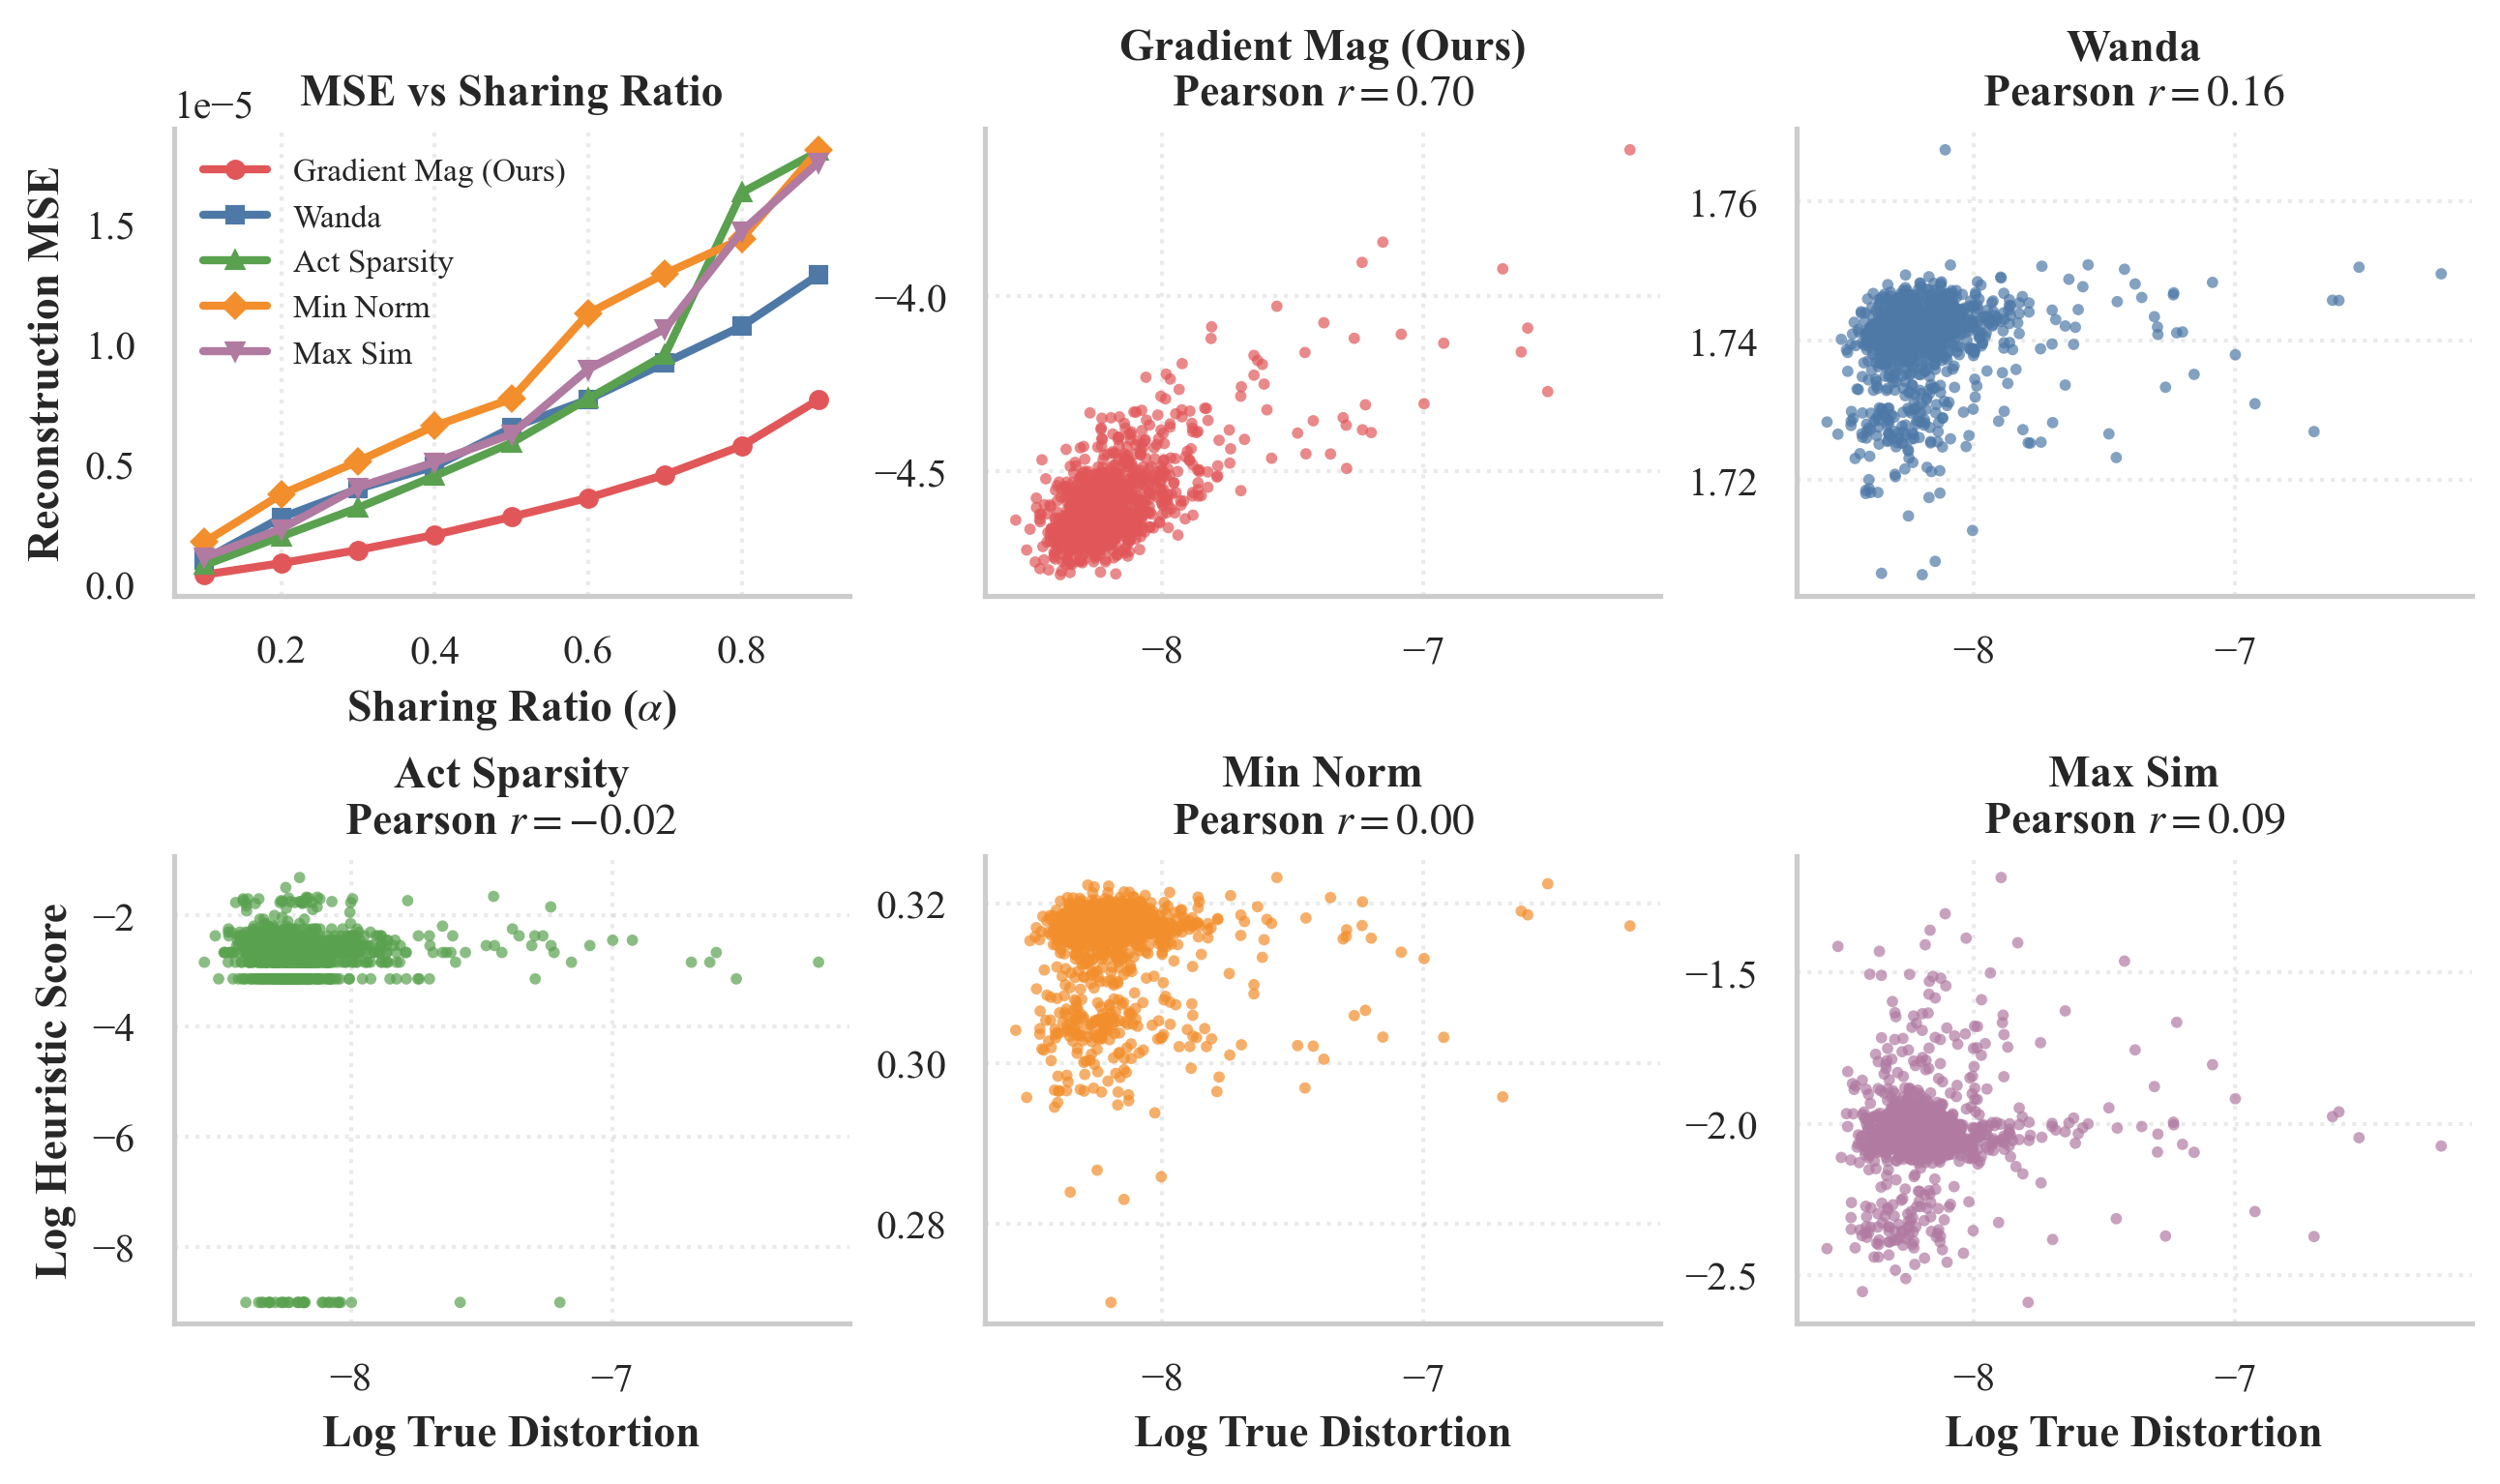

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import torch
from typing import Dict, List, Tuple


def plot_motivation_figure(
    ratios: List[float],
    curves: Dict[str, List[float]],
    method_order: List[str],
    method_labels: Dict[str, str],
    oracle_distortion: torch.Tensor,
    importance_scores: Dict[str, torch.Tensor],
    save_path: str,
) -> None:
    oracle_np: np.ndarray = oracle_distortion.float().cpu().numpy()
    eps: float = 1e-9

    fig: plt.Figure
    axes: np.ndarray
    fig, axes = plt.subplots(2, 3, figsize=(8.5, 5.0), constrained_layout=True)

    line_ax: plt.Axes = axes[0, 0]
    for method in method_order:
        line_ax.plot(
            ratios,
            curves[method],
            label=method_labels[method],
            color=METHOD_COLORS[method],
            marker=METHOD_MARKERS[method],
            markersize=4,
            linewidth=2.0,
        )

    line_ax.set_title("MSE vs Sharing Ratio")
    line_ax.set_xlabel(r"Sharing Ratio ($\alpha$)")
    line_ax.set_ylabel("Reconstruction MSE")
    line_ax.set_axisbelow(True)
    line_ax.grid(axis="y")
    line_ax.legend(frameon=False, ncol=1, fontsize=8)

    scatter_positions: List[Tuple[int, int]] = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]
    scatter_methods: List[str] = method_order

    for (row, col), method_name in zip(scatter_positions, scatter_methods):
        ax: plt.Axes = axes[row, col]
        scores_np: np.ndarray = importance_scores[method_name].float().cpu().numpy()
        x_data: np.ndarray = np.log10(oracle_np + eps)
        y_data: np.ndarray = np.log10(scores_np + eps)
        corr: float = float(pearsonr(x_data, y_data)[0])

        ax.scatter(
            x_data,
            y_data,
            alpha=0.7,
            s=8,
            color=METHOD_COLORS[method_name],
            edgecolors="none",
        )
        ax.set_title(
            f"{method_labels[method_name]}\nPearson $r={corr:.2f}$",
            fontsize=11,
            fontweight="bold",
        )

        if row == 1:
            ax.set_xlabel("Log True Distortion")
        else:
            ax.set_xlabel("")

        if col == 0:
            ax.set_ylabel("Log Heuristic Score")
        else:
            ax.set_ylabel("")

        ax.set_axisbelow(True)
        ax.grid(True, linestyle=":", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_motivation_figure(
    RATIOS,
    curves,
    method_order,
    method_labels,
    true_distortion_valid,
    importance_scores,
    save_path=f"motivation_{model.config.model_type}_layer_{LAYER_IDX}.pdf",
)
